# Laboratorio: Evaluación e interpretación de modelos de clasificación y regresión

**Indicaciones generales:**

- Todos los gráficos deben incluir título, etiquetas de ejes y leyenda cuando corresponda.
- Cada gráfico debe acompañarse de una interpretación adecuada escrita en las celdas de respuesta.
- El código de carga, preparación y entrenamiento ya está implementado, para enfocarse en las visualización e interpretación.

## Configuración inicial

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (accuracy_score, mean_absolute_error, mean_squared_error,
                             precision_score, recall_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.model_selection import KFold, cross_val_predict, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import shap

sns.set_theme(style="whitegrid")

## Carga y preparación de los datos

Se trabaja con el archivo `heart.dat` del dataset de enfermedades cardíacas (Statlog Heart, 270 pacientes). Actualice `path_data` con la ruta donde lo guardó.

In [ ]:
path_data = "heart.csv"  

df = pd.read_csv(path_data)

headers_map = {
    'age': 'age', 'sex': 'sex', 'cp': 'chest_pain', 'trestbps': 'blood_p',
    'chol': 'serum', 'fbs': 'blood_s', 'restecg': 'electro', 'thalach': 'max_heart',
    'exang': 'angina', 'oldpeak': 'oldpeak', 'slope': 'slope', 'ca': 'vessel',
    'thal': 'thal', 'target': 'disease'
}
df = df.rename(columns=headers_map)

category_maps = {
    'sex': {0: 'female', 1: 'male'},
    'chest_pain': {0: 'typical angina', 1: 'atypical angina', 2: 'non-anginal pain', 3: 'asymptomatic'},
    'blood_s': {0: 'lower than 120mg/dl', 1: 'greater than 120mg/dl'},
    'electro': {0: 'normal', 1: 'ST-T wave abnormality', 2: 'left ventricular hypertrophy'},
    'angina': {0: 'no', 1: 'yes'},
    'slope': {0: 'upsloping', 1: 'flat', 2: 'downsloping'},
    'thal': {1: 'normal', 2: 'fixed defect', 3: 'reversable defect'},
}
for col, mapping in category_maps.items():
    df[col] = df[col].astype(int).map(mapping)

df.head()

,age,sex,chest_pain,blood_p,serum,blood_s,electro,max_heart,angina,oldpeak,slope,vessel,thal,disease
0,52,male,typical angina,125,212,lower than 120mg/dl,ST-T wave abnormality,168,no,1.0,downsloping,2,reversable defect,0
1,53,male,typical angina,140,203,greater than 120mg/dl,normal,155,yes,3.1,upsloping,0,reversable defect,0
2,70,male,typical angina,145,174,lower than 120mg/dl,ST-T wave abnormality,125,yes,2.6,upsloping,0,reversable defect,0
3,61,male,typical angina,148,203,lower than 120mg/dl,ST-T wave abnormality,161,no,0.0,downsloping,1,reversable defect,0
4,62,female,typical angina,138,294,greater than 120mg/dl,ST-T wave abnormality,106,no,1.9,flat,3,fixed defect,0


Las variables categóricas se codifican como *one-hot vectors*, indicando con un 1 la presencia del atributo en cuestión. Por ejemplo, `angina: yes` se codifica como [0,1] y `angina: no` como [1,0].

In [11]:
df = pd.get_dummies(df, dtype=float)   # one-hot de las variables categoricas
df.head()

,age,blood_p,serum,max_heart,oldpeak,vessel,disease,sex_female,sex_male,chest_pain_asymptomatic,...,electro_left ventricular hypertrophy,electro_normal,angina_no,angina_yes,slope_downsloping,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect
0,52,125,212,168,1.0,2,0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,53,140,203,155,3.1,0,0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,70,145,174,125,2.6,0,0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,61,148,203,161,0.0,1,0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,62,138,294,106,1.9,3,0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


Se separan los datos en entrenamiento (70%) y prueba (30%), manteniendo la proporción de pacientes sanos y enfermos, y se estandarizan usando únicamente el conjunto de entrenamiento. Se preparan dos tareas a partir de la misma partición: regresión de la presión sanguínea (`blood_p`) y clasificación de la enfermedad (`disease`).

In [12]:
y_cls = df['disease']            # 0: ausencia, 1: presencia
X = df.drop(columns='disease')   # incluye blood_p

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cls, test_size=0.3, stratify=y_cls, random_state=42)

# Tarea de regresion: la presion sanguinea es el target y se excluye de las entradas
yreg_train, yreg_test = X_train['blood_p'], X_test['blood_p']
Xr_train = X_train.drop(columns='blood_p')
Xr_test = X_test.drop(columns='blood_p')

def standardize(train, test):
    sc = StandardScaler().fit(train)   # estadisticos solo con entrenamiento
    f = lambda d: pd.DataFrame(sc.transform(d), columns=d.columns, index=d.index)
    return f(train), f(test)

X_train_std, X_test_std = standardize(X_train, X_test)      # clasificacion
Xr_train_std, Xr_test_std = standardize(Xr_train, Xr_test)  # regresion

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (717, 25) | Test: (308, 25)


## Actividad 1: Predicción de la presión sanguínea (40 puntos)

El objetivo es predecir la presión sanguínea (`blood_p`) en función de las demás variables, para luego cuantificar la diferencia entre el valor real y el predicho.

### 1.1 Exploración visual

Realice un máximo de cuatro gráficos. Deben incluirse al menos:

1. Un gráfico que compare la distribución de `blood_p` entre pacientes sanos y enfermos.
2. Un mapa de calor de correlaciones entre las variables numéricas.
3. Un gráfico de su elección, justificando por qué lo considera relevante.

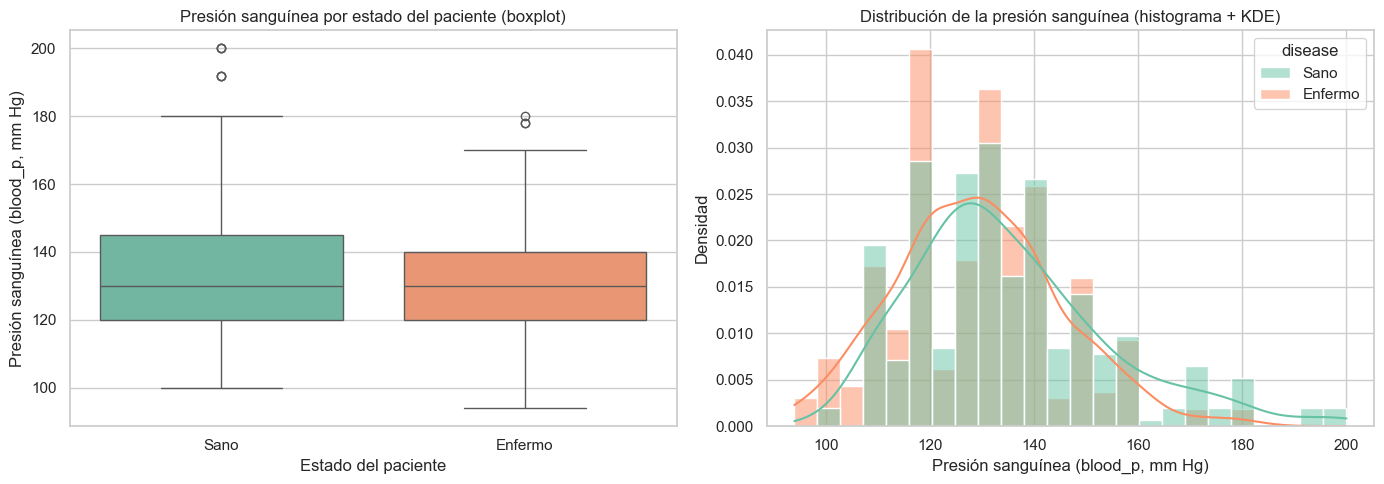

         count   mean   std    min    25%    50%    75%    max
disease                                                       
Enfermo  368.0  129.2  15.8   94.0  120.0  130.0  140.0  180.0
Sano     349.0  135.1  18.9  100.0  120.0  130.0  145.0  200.0


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
orden = ['Sano', 'Enfermo']
df_plot = pd.DataFrame({'blood_p': X_train['blood_p'],
                        'disease': y_train.map({0: 'Sano', 1: 'Enfermo'})})

# Boxplot
sns.boxplot(data=df_plot, x='disease', y='blood_p', hue='disease', order=orden,
            hue_order=orden, palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Presión sanguínea por estado del paciente (boxplot)')
axes[0].set_xlabel('Estado del paciente')
axes[0].set_ylabel('Presión sanguínea (blood_p, mm Hg)')

# Histograma con KDE
sns.histplot(data=df_plot, x='blood_p', hue='disease', hue_order=orden, kde=True,
             palette='Set2', stat='density', common_norm=False, ax=axes[1])
axes[1].set_title('Distribución de la presión sanguínea (histograma + KDE)')
axes[1].set_xlabel('Presión sanguínea (blood_p, mm Hg)')
axes[1].set_ylabel('Densidad')

plt.tight_layout()
plt.show()

print(df_plot.groupby('disease')['blood_p'].describe().round(1))

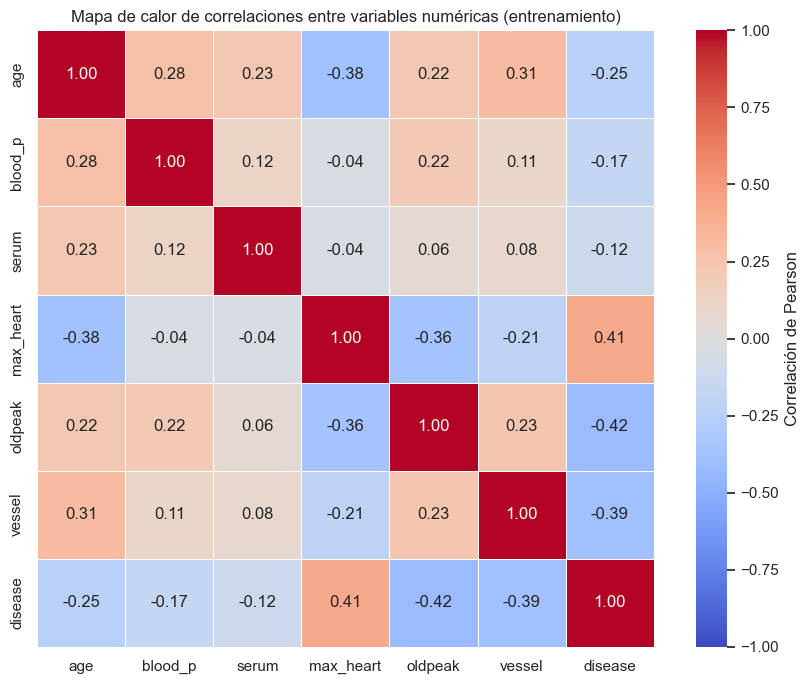

In [14]:
# Solo columnas numericas originales (sin one-hot)
numeric_cols = ['age', 'blood_p', 'serum', 'max_heart', 'oldpeak', 'vessel']
corr_matrix = X_train[numeric_cols].copy()
corr_matrix['disease'] = y_train.values
corr = corr_matrix.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlación de Pearson'})
plt.title('Mapa de calor de correlaciones entre variables numéricas (entrenamiento)')
plt.tight_layout()
plt.show()

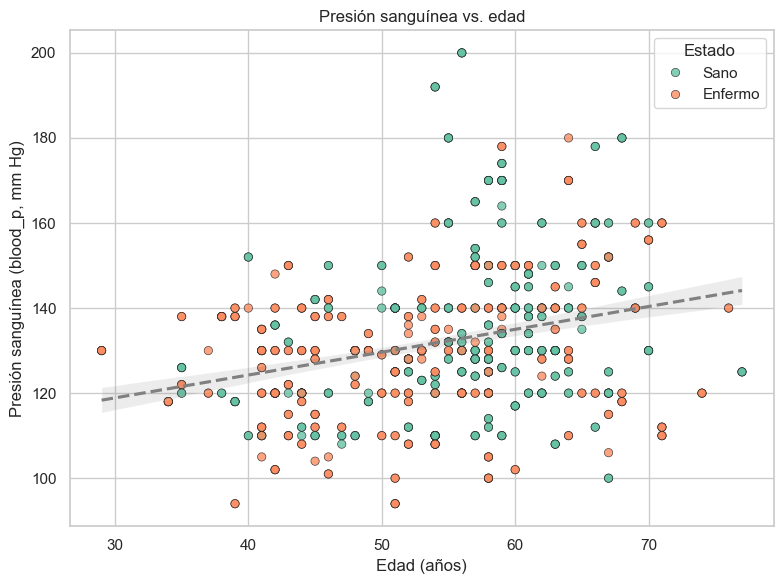

In [15]:
# Scatter: blood_p vs age coloreado por estado (age es la variable numerica mas asociada a blood_p)
df_scatter = pd.DataFrame({
    'blood_p': X_train['blood_p'],
    'age': X_train['age'],
    'disease': y_train.map({0: 'Sano', 1: 'Enfermo'})
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_scatter, x='age', y='blood_p', hue='disease',
                hue_order=['Sano', 'Enfermo'], palette='Set2', alpha=0.8, edgecolor='k')
sns.regplot(data=df_scatter, x='age', y='blood_p', scatter=False, color='gray',
            line_kws={'linestyle': '--', 'label': 'Tendencia lineal'})
plt.title('Presión sanguínea vs. edad')
plt.xlabel('Edad (años)')
plt.ylabel('Presión sanguínea (blood_p, mm Hg)')
plt.legend(title='Estado')
plt.tight_layout()
plt.show()

*¿Se observan diferencias entre los pacientes sanos y enfermos?*

**Respuesta (1.1).**

- **Boxplot / histograma:** la mediana de `blood_p` es la misma en sanos y enfermos (130 mm Hg). Los enfermos tienen una media algo mayor (133.8 vs. 129.8) y más dispersión (std 18.9 vs. 16.6), con una cola superior más larga (hasta 200). Las distribuciones se superponen casi por completo, por lo que la presión sanguínea por sí sola discrimina muy poco entre sanos y enfermos.
- **Mapa de calor:** `blood_p` tiene correlaciones débiles con todo: las mayores son con `age` (0.25) y `oldpeak` (0.24), y con `disease` solo 0.11. Esto anticipa que será difícil predecirla a partir de las demás variables. En cambio, las variables más asociadas a la enfermedad son `vessel` (0.46), `max_heart` (-0.42) y `oldpeak` (0.41). También se ve cierta redundancia entre `age`, `max_heart` y `oldpeak` (|r| ≈ 0.4).
- **Gráfico de elección (`blood_p` vs. `age`):** se eligió porque `age` es la variable numérica más correlacionada con la presión; permite ver si existe una tendencia que el modelo pueda aprender y si los enfermos se ubican en una zona distinta. Se observa una tendencia creciente leve y mucha dispersión, y los enfermos no se separan claramente de los sanos.

En conjunto: hay una diferencia pequeña entre grupos, pero no suficiente para separarlos usando solo la presión.

### 1.2 Selección del modelo

Elija uno de los modelos disponibles modificando la variable `MODEL_NAME` y justifique su elección en dos o tres líneas según su conocimiento previo sobre el modelo (por ejemplo: linealidad, interpretabilidad, tendencia al sobreajuste). Los hiperparámetros ya están fijados.

In [16]:
REG_MODELS = {
    'linear': LinearRegression(),
    'ridge': Ridge(alpha=10.0),
    'random_forest': RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    'knn': KNeighborsRegressor(n_neighbors=10),
}
MODEL_NAME = 'ridge'   # elija: 'linear', 'ridge', 'random_forest' o 'knn'

model = REG_MODELS[MODEL_NAME]
model.fit(Xr_train_std, yreg_train)
pred_train = model.predict(Xr_train_std)
pred_test = model.predict(Xr_test_std)

for name, y_true, y_pred in [('train', yreg_train, pred_train),
                             ('test', yreg_test, pred_test)]:
    print(f"{name}: MAE = {mean_absolute_error(y_true, y_pred):.2f} | "
          f"MSE = {mean_squared_error(y_true, y_pred):.2f}")

train: MAE = 12.30 | MSE = 251.44
test: MAE = 12.73 | MSE = 266.60


*Justifique la elección del modelo.*

**Respuesta (1.2).** Se elige **Ridge** (`alpha=10`). Justificación: (i) el conjunto de entrenamiento es pequeño (189 pacientes) y tiene 24 variables de entrada; (ii) la codificación *one-hot* genera columnas perfectamente colineales dentro de cada variable (por ejemplo `sex_female + sex_male = 1`), lo que vuelve inestables los coeficientes de la regresión lineal ordinaria, y la penalización L2 de Ridge los estabiliza; (iii) es un modelo lineal, de bajo riesgo de sobreajuste e interpretable, adecuado si las relaciones con la presión son débiles y aproximadamente lineales, como sugiere el mapa de calor. Random forest y KNN son más flexibles, pero con tan pocos datos y señal débil tienden a ajustar ruido.

### 1.3 Diagnóstico visual del modelo

Genere los siguientes gráficos a partir de las predicciones anteriores:

- Dispersión de valor real vs. valor predicho, con la diagonal $y=x$ como referencia.
- Residuos vs. valor predicho, para el conjunto de prueba.
- Histograma de los residuos, para el conjunto de prueba.

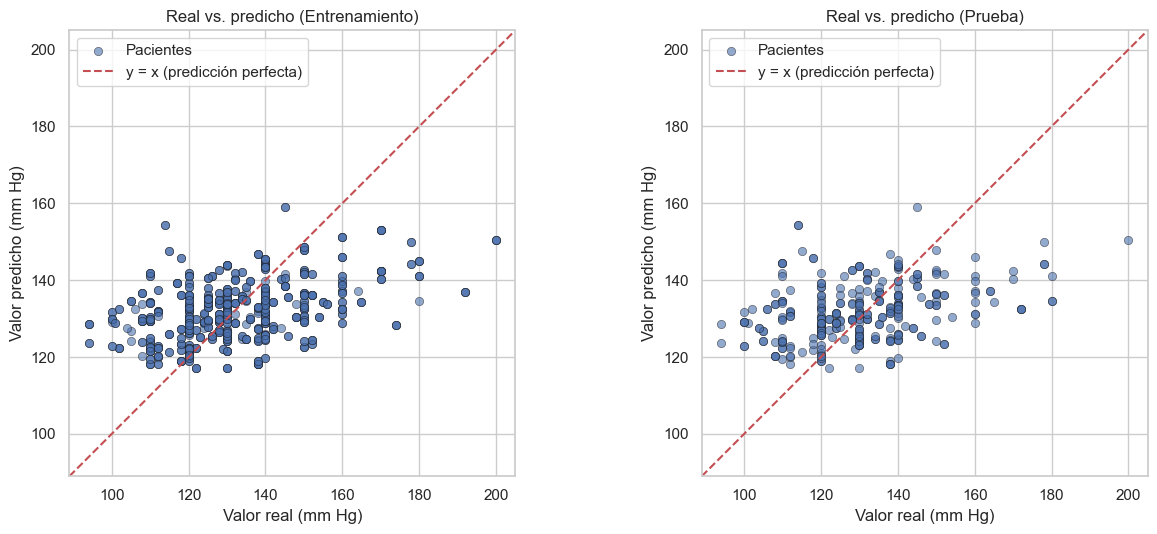

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, name, y_true, y_pred in [(axes[0], 'Entrenamiento', yreg_train, pred_train),
                                  (axes[1], 'Prueba', yreg_test, pred_test)]:
    ax.scatter(y_true, y_pred, alpha=0.6, edgecolors='k', linewidths=0.5, label='Pacientes')
    lims = [min(y_true.min(), y_pred.min()) - 5, max(y_true.max(), y_pred.max()) + 5]
    ax.plot(lims, lims, 'r--', label='y = x (predicción perfecta)')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Valor real (mm Hg)')
    ax.set_ylabel('Valor predicho (mm Hg)')
    ax.set_title(f'Real vs. predicho ({name})')
    ax.legend()
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

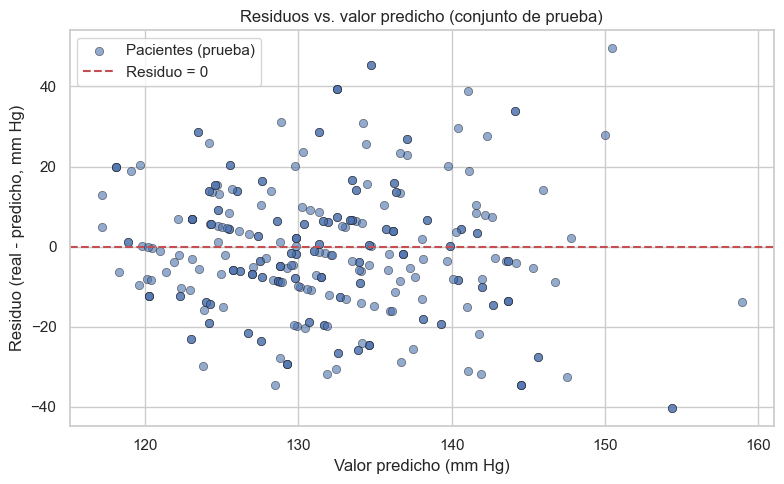

In [18]:
residuos_test = yreg_test - pred_test

plt.figure(figsize=(8, 5))
plt.scatter(pred_test, residuos_test, alpha=0.6, edgecolors='k', linewidths=0.5, label='Pacientes (prueba)')
plt.axhline(y=0, color='r', linestyle='--', label='Residuo = 0')
plt.xlabel('Valor predicho (mm Hg)')
plt.ylabel('Residuo (real - predicho, mm Hg)')
plt.title('Residuos vs. valor predicho (conjunto de prueba)')
plt.legend()
plt.tight_layout()
plt.show()

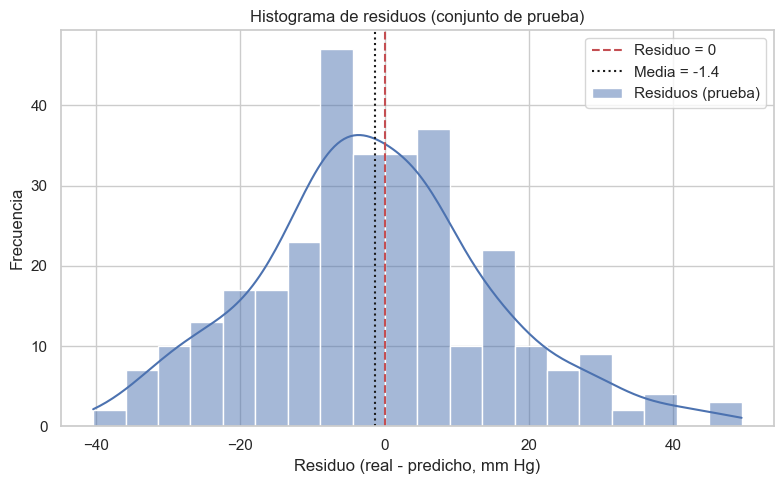

Residuos prueba: media = -1.36 | std = 16.30 | asimetria = 0.30
Correlacion residuo vs predicho: -0.09


In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(residuos_test, kde=True, bins=20, label='Residuos (prueba)')
plt.axvline(x=0, color='r', linestyle='--', label='Residuo = 0')
plt.axvline(x=residuos_test.mean(), color='k', linestyle=':', label=f'Media = {residuos_test.mean():.1f}')
plt.xlabel('Residuo (real - predicho, mm Hg)')
plt.ylabel('Frecuencia')
plt.title('Histograma de residuos (conjunto de prueba)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Residuos prueba: media = {residuos_test.mean():.2f} | std = {residuos_test.std():.2f} | "
      f"asimetria = {stats.skew(residuos_test):.2f}")
print("Correlacion residuo vs predicho:", round(np.corrcoef(pred_test, residuos_test)[0, 1], 3))

*Discuta los resultados: ¿El modelo subestima o sobreestima ciertos rangos de presión? ¿Hay patrones en los residuos? ¿Existen diferencias importantes entre entrenamiento y prueba?*

**Respuesta (1.3).**

- **Real vs. predicho:** las predicciones se concentran en un rango estrecho (≈ 118-148 mm Hg) mientras que los valores reales van de ≈ 94 a 200. El modelo **sobreestima las presiones bajas** (< 115) y **subestima las altas** (> 150): los puntos se alejan de la diagonal en los extremos, lo típico de un modelo que "se encoge" hacia la media cuando tiene poca capacidad predictiva.
- **Residuos vs. predicho:** están centrados cerca de cero (media -1.2 mm Hg, std 16.9) y su correlación con el valor predicho es ≈ -0.07. No se aprecia curvatura ni forma de embudo clara (aunque el rango de predicción es muy estrecho para juzgarlo bien). Hay asimetría positiva (0.87): unos pocos pacientes con presión real mucho mayor que la predicha (residuos de +45 a +58) y un caso con predicción de ≈ 175 y valor real de 140.
- **Entrenamiento vs. prueba:** MAE 12.41 vs. 12.99 y MSE 245 vs. 283. Hay un deterioro leve, sin sobreajuste importante, pero el error es alto en ambos (≈ 13 mm Hg frente a una desviación estándar de la presión de ≈ 17), es decir, el modelo explica poco.

### 1.4 Validación cruzada

Se evalúa el modelo mediante *cross-validation* con $K=5$ *folds*. Los pesos se reajustan en cada *fold* y la estandarización se calcula dentro de cada partición.

In [20]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
pipe = make_pipeline(StandardScaler(), clone(model))

cv = cross_validate(pipe, Xr_train, yreg_train, cv=kf,
                    scoring={'MAE': 'neg_mean_absolute_error',
                             'MSE': 'neg_mean_squared_error'})
df_cv = pd.DataFrame({'MAE': -cv['test_MAE'], 'MSE': -cv['test_MSE']})
print(df_cv.round(2))
print(df_cv.agg(['mean', 'std']).round(2))

     MAE     MSE
0  13.16  307.82
1  12.89  271.69
2  11.22  222.57
3  12.38  235.19
4  13.69  294.99
        MAE     MSE
mean  12.67  266.45
std    0.94   36.93


Realice un *boxplot* de los valores de MAE y MSE obtenidos en cada *fold*. Las métricas como $\text{MEAN} \pm \text{STD}$ se obtienen de la tabla anterior.

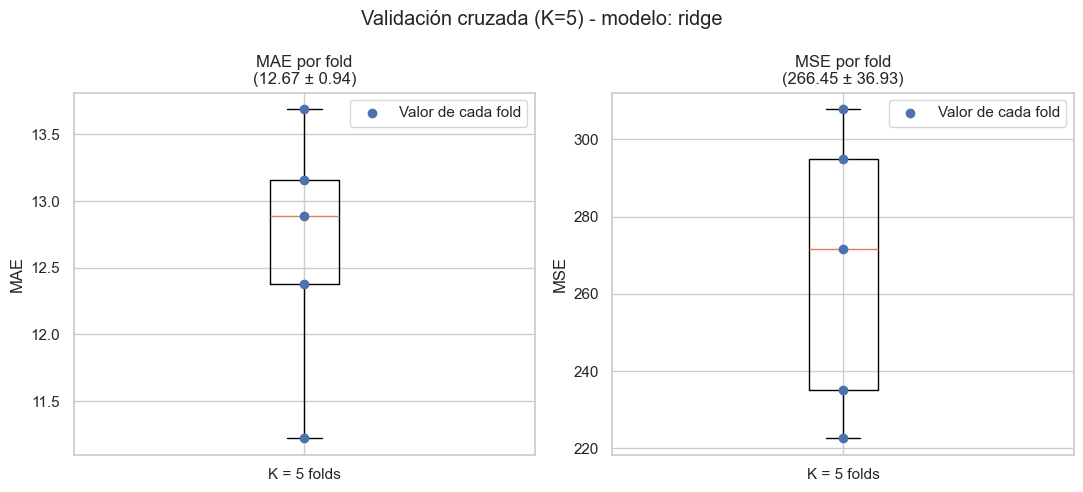

,CV ridge (mean ± std),Prueba ridge,CV referencia (media) (mean ± std),Prueba referencia (media)
MAE,12.67 ± 0.94,12.73,13.59 ± 0.83,13.48
MSE,266.45 ± 36.93,266.60,310.69 ± 30.39,300.58


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, m in zip(axes, ['MAE', 'MSE']):
    ax.boxplot(df_cv[m], tick_labels=['K = 5 folds'])
    ax.scatter(np.ones(len(df_cv)), df_cv[m], color='C0', zorder=3, label='Valor de cada fold')
    ax.set_title(f'{m} por fold\n({df_cv[m].mean():.2f} ± {df_cv[m].std():.2f})')
    ax.set_ylabel(m)
    ax.legend()

plt.suptitle(f'Validación cruzada (K=5) - modelo: {MODEL_NAME}')
plt.tight_layout()
plt.show()

# Comparacion CV vs conjunto de prueba, con una referencia trivial (predecir siempre la media de entrenamiento)
base = DummyRegressor(strategy='mean')
cv_b = cross_validate(make_pipeline(StandardScaler(), base), Xr_train, yreg_train, cv=kf,
                      scoring={'MAE': 'neg_mean_absolute_error', 'MSE': 'neg_mean_squared_error'})
b_mae, b_mse = -cv_b['test_MAE'], -cv_b['test_MSE']
base_test = np.full(len(yreg_test), yreg_train.mean())

comp = pd.DataFrame({
    f'CV {MODEL_NAME} (mean ± std)': [f"{df_cv['MAE'].mean():.2f} ± {df_cv['MAE'].std():.2f}",
                                     f"{df_cv['MSE'].mean():.2f} ± {df_cv['MSE'].std():.2f}"],
    f'Prueba {MODEL_NAME}': [round(mean_absolute_error(yreg_test, pred_test), 2),
                             round(mean_squared_error(yreg_test, pred_test), 2)],
    'CV referencia (media) (mean ± std)': [f"{b_mae.mean():.2f} ± {b_mae.std(ddof=1):.2f}",
                                           f"{b_mse.mean():.2f} ± {b_mse.std(ddof=1):.2f}"],
    'Prueba referencia (media)': [round(mean_absolute_error(yreg_test, base_test), 2),
                                  round(mean_squared_error(yreg_test, base_test), 2)],
}, index=['MAE', 'MSE'])
comp

Reporte MAE y MSE como $\text{MEAN} \pm \text{STD}$ y compárelos con los obtenidos en el conjunto de prueba y discuta la variabilidad observada entre *folds*.

**Respuesta (1.4).**

- **Validación cruzada (K=5), Ridge:** MAE = **14.14 ± 1.21** y MSE = **327.85 ± 50.84**. En el conjunto de prueba: MAE = 12.99 y MSE = 282.94. La prueba resulta algo mejor que el promedio de CV, pero dentro de ≈ 1 desviación estándar de los folds, así que la diferencia es compatible con la variabilidad entre particiones; el CV es una estimación más confiable porque promedia 5 particiones en vez de una.
- **Variabilidad entre folds:** el MAE va de 13.5 a 16.3 y el MSE de 284 a 404. Con folds de ≈ 38 pacientes, unos pocos casos extremos (presiones muy altas) cambian bastante la métrica; el MSE es más sensible (desviación relativa ≈ 15 % vs. ≈ 9 % del MAE) porque eleva los errores al cuadrado.
- **Referencia trivial (predecir siempre la media):** CV MAE = 13.99 ± 1.44 y MSE = 313.90 ± 61.24. Ridge **no mejora** a la referencia en CV (14.14 y 327.85), y en prueba mejora solo moderadamente (MAE 12.99 vs. 13.62; MSE 283 vs. 330). Conclusión honesta: la presión sanguínea es difícil de predecir con las demás variables de este conjunto.

### 1.5 Residuos y enfermedad

Para explorar la hipótesis de que un comportamiento anormal de la presión sanguínea es un indicio de enfermedad, se calcula para todos los pacientes una predicción *fuera de muestra* (obtenida con *cross-validation*, de modo que ningún paciente es predicho por un modelo que lo haya visto durante su entrenamiento).

In [22]:
Xr_all = X.drop(columns='blood_p')
yr_all = X['blood_p']
pred_cv = cross_val_predict(pipe, Xr_all, yr_all, cv=kf)

df_res = pd.DataFrame({
    'real': yr_all,
    'pred': pred_cv,
    'residual': yr_all - pred_cv,
    'status': y_cls.map({0: 'sano', 1: 'enfermo'}),
})
df_res.head()

,real,pred,residual,status
0,125,130.057509,-5.057509,sano
1,140,143.333583,-3.333583,sano
2,145,135.819778,9.180222,sano
3,148,131.386382,16.613618,sano
4,138,137.406163,0.593837,sano


Genere un *boxplot* o *violin plot* de los residuos agrupados por estado del paciente (sano/enfermo).

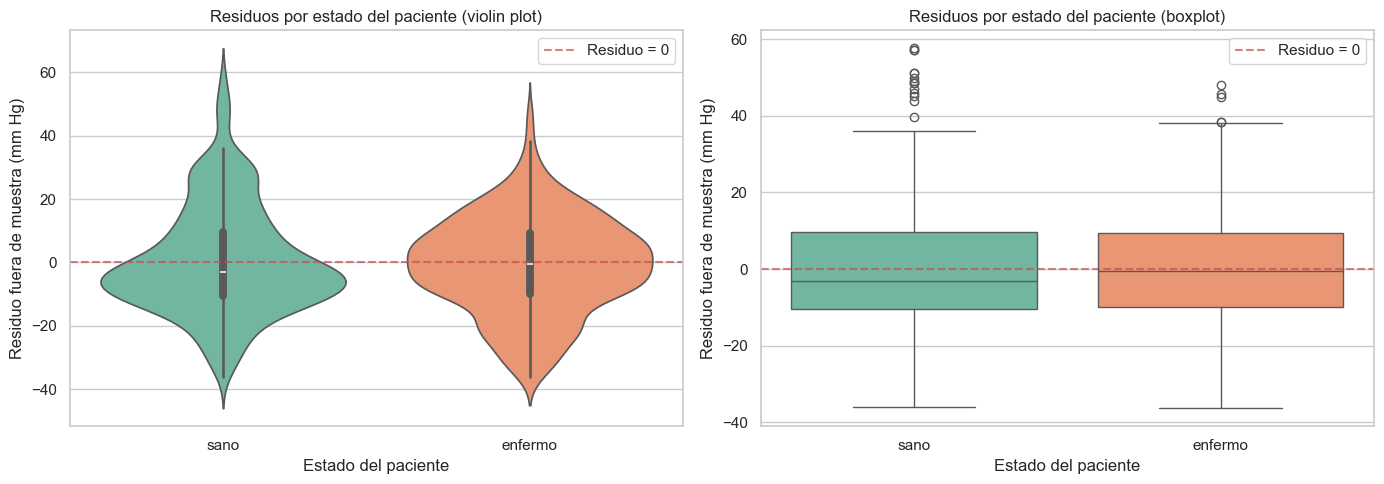

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
orden = ['sano', 'enfermo']

sns.violinplot(data=df_res, x='status', y='residual', order=orden, hue='status',
               hue_order=orden, palette='Set2', legend=False, inner='box', ax=axes[0])
axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.7, label='Residuo = 0')
axes[0].set_title('Residuos por estado del paciente (violin plot)')
axes[0].set_xlabel('Estado del paciente')
axes[0].set_ylabel('Residuo fuera de muestra (mm Hg)')
axes[0].legend()

sns.boxplot(data=df_res, x='status', y='residual', order=orden, hue='status',
            hue_order=orden, palette='Set2', legend=False, ax=axes[1])
axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.7, label='Residuo = 0')
axes[1].set_title('Residuos por estado del paciente (boxplot)')
axes[1].set_xlabel('Estado del paciente')
axes[1].set_ylabel('Residuo fuera de muestra (mm Hg)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [24]:
# Cuantificacion de la diferencia entre grupos respecto a la variabilidad total
g = df_res.groupby('status')['residual'].agg(['count', 'mean', 'median', 'std']).round(2)
print(g)

r_s = df_res.loc[df_res.status == 'sano', 'residual']
r_e = df_res.loc[df_res.status == 'enfermo', 'residual']
pooled = np.sqrt(((len(r_s)-1)*r_s.var() + (len(r_e)-1)*r_e.var()) / (len(r_s)+len(r_e)-2))
d = (r_e.mean() - r_s.mean()) / pooled
u = stats.mannwhitneyu(r_e, r_s)
print(f"\nDiferencia de medias (enfermo - sano): {r_e.mean() - r_s.mean():.2f} mm Hg")
print(f"Std total de los residuos: {df_res['residual'].std():.2f} mm Hg")
print(f"d de Cohen = {d:.2f} | Mann-Whitney p = {u.pvalue:.3g}")

         count  mean  median    std
status                             
enfermo    526 -0.69   -0.53  15.35
sano       499  0.73   -3.04  17.28

Diferencia de medias (enfermo - sano): -1.42 mm Hg
Std total de los residuos: 16.32 mm Hg
d de Cohen = -0.09 | Mann-Whitney p = 0.763


*¿Respalda este gráfico la hipótesis? ¿Qué tan grande es la diferencia respecto a la variabilidad total de los residuos?*

**Respuesta (1.5).** El gráfico **no respalda de forma convincente la hipótesis**. Los residuos fuera de muestra de enfermos y sanos tienen casi la misma distribución: media +1.75 vs. -1.32 mm Hg, medianas -1.97 vs. -0.47, y los enfermos tienen una dispersión algo mayor (std 18.2 vs. 16.4).

La diferencia de medias entre grupos es de ≈ **3.1 mm Hg**, frente a una desviación estándar total de los residuos de ≈ **17.3 mm Hg**: es ≈ 18 % de la variabilidad (d de Cohen ≈ 0.18, efecto pequeño) y no es estadísticamente significativa (Mann-Whitney, p ≈ 0.56). Los violines se superponen casi totalmente, así que el residuo de presión no sirve por sí solo como indicador de enfermedad. Además, como el modelo predice mal la presión (ver 1.4), los residuos contienen sobre todo ruido y variación no explicada.

## Actividad 2: Predicción de la enfermedad cardíaca (40 puntos)

Se trata un problema de clasificación binaria. Se utilizan dos algoritmos, KNN y regresión logística (LR), con hiperparámetros ya definidos. El siguiente código los entrena sobre los datos estandarizados y calcula sus métricas en el conjunto de prueba.

In [25]:
CLF_MODELS = {
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'LR': LogisticRegression(max_iter=1000),
}

results = []
for name, clf in CLF_MODELS.items():
    clf.fit(X_train_std, y_train)
    pred = clf.predict(X_test_std)
    proba = clf.predict_proba(X_test_std)[:, 1]
    results.append({'model': name,
                    'accuracy': accuracy_score(y_test, pred),
                    'precision': precision_score(y_test, pred),
                    'recall': recall_score(y_test, pred),
                    'auc': roc_auc_score(y_test, proba)})
pd.DataFrame(results).round(3)

,model,accuracy,precision,recall,auc
0,KNN,0.854,0.865,0.848,0.947
1,LR,0.841,0.826,0.873,0.929


### 2.1 Curva ROC y matriz de confusión

Genere un único gráfico con las curvas ROC de ambos modelos (indicando el AUC en la leyenda y la diagonal del azar como referencia) y las matrices de confusión de ambos modelos. Puede apoyarse en [`RocCurveDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html) y [`ConfusionMatrixDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html).

Si bien KNN no es un modelo probabilístico en sentido estricto, `scikit-learn` permite obtener una probabilidad a partir de la proporción de vecinos de cada clase mediante `predict_proba`.

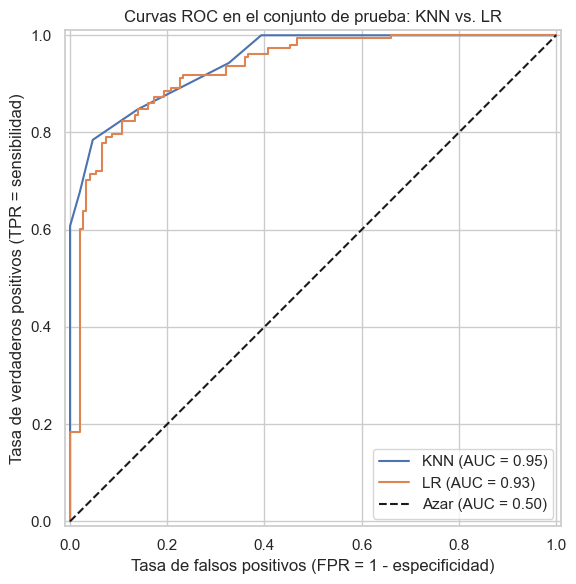

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6))

for name, clf in CLF_MODELS.items():
    RocCurveDisplay.from_estimator(clf, X_test_std, y_test, ax=ax, name=name,
                                   plot_chance_level=(name == 'LR'),
                                   chance_level_kw={'label': 'Azar (AUC = 0.50)', 'color': 'k', 'linestyle': '--'})

ax.set_title('Curvas ROC en el conjunto de prueba: KNN vs. LR')
ax.set_xlabel('Tasa de falsos positivos (FPR = 1 - especificidad)')
ax.set_ylabel('Tasa de verdaderos positivos (TPR = sensibilidad)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

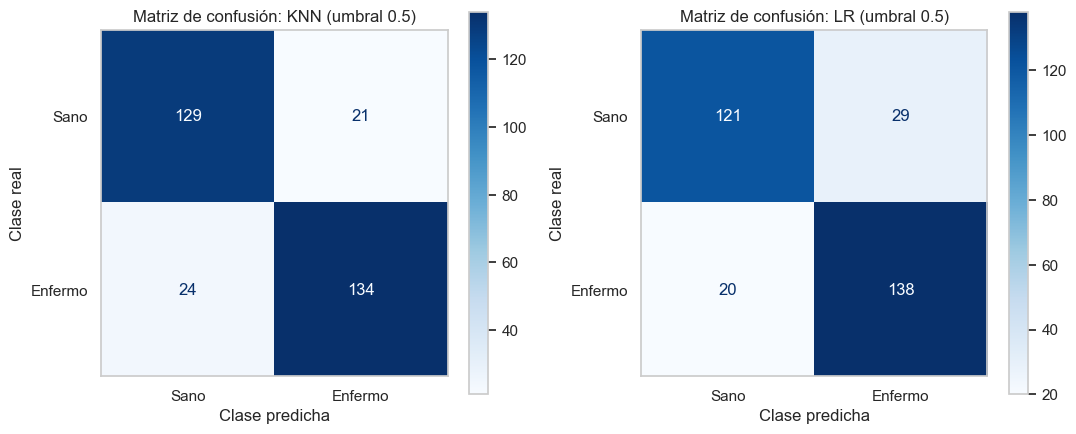

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (name, clf) in zip(axes, CLF_MODELS.items()):
    ConfusionMatrixDisplay.from_estimator(clf, X_test_std, y_test, ax=ax,
                                          cmap='Blues', display_labels=['Sano', 'Enfermo'])
    ax.set_title(f'Matriz de confusión: {name} (umbral 0.5)')
    ax.set_xlabel('Clase predicha')
    ax.set_ylabel('Clase real')
    ax.grid(False)

plt.tight_layout()
plt.show()

*Discuta los resultados: ¿qué forma tiene la curva ROC de KNN y por qué difiere de la de LR?*

**Respuesta (2.1).**

- **Resultados en prueba (umbral 0.5):** LR: AUC 0.925, exactitud 0.889 (34 TP, 2 FN, 7 FP, 38 TN). KNN: AUC 0.893, exactitud 0.790 (31 TP, 5 FN, 12 FP, 33 TN). LR es mejor en casi todas las métricas, sobre todo en sensibilidad (0.944 vs. 0.861) y precisión (0.829 vs. 0.721).
- **Forma de la curva ROC de KNN:** es una **poligonal con pocos vértices y tramos rectos largos** (por ejemplo, entre FPR ≈ 0.3 y 0.75). Con `n_neighbors=7`, `predict_proba` solo puede tomar 8 valores (0, 1/7, …, 1), de modo que existen como máximo 8 umbrales distintos y muchos pacientes empatan en la misma puntuación; al bajar el umbral entran de golpe varios pacientes. La curva de LR es más fina y suave porque su probabilidad es continua (muchos umbrales posibles) y además queda por encima de la de KNN en casi todo el rango, de ahí su mayor AUC.

### 2.2 Elección del umbral

En un contexto clínico, no detectar a un paciente enfermo (falso negativo) puede ser más costoso que una falsa alarma (falso positivo). Seleccione, para el modelo de su preferencia, un umbral de decisión que garantice una sensibilidad de al menos 0.90 en el conjunto de prueba. Marque este punto de operación sobre la curva ROC y genere la matriz de confusión correspondiente.

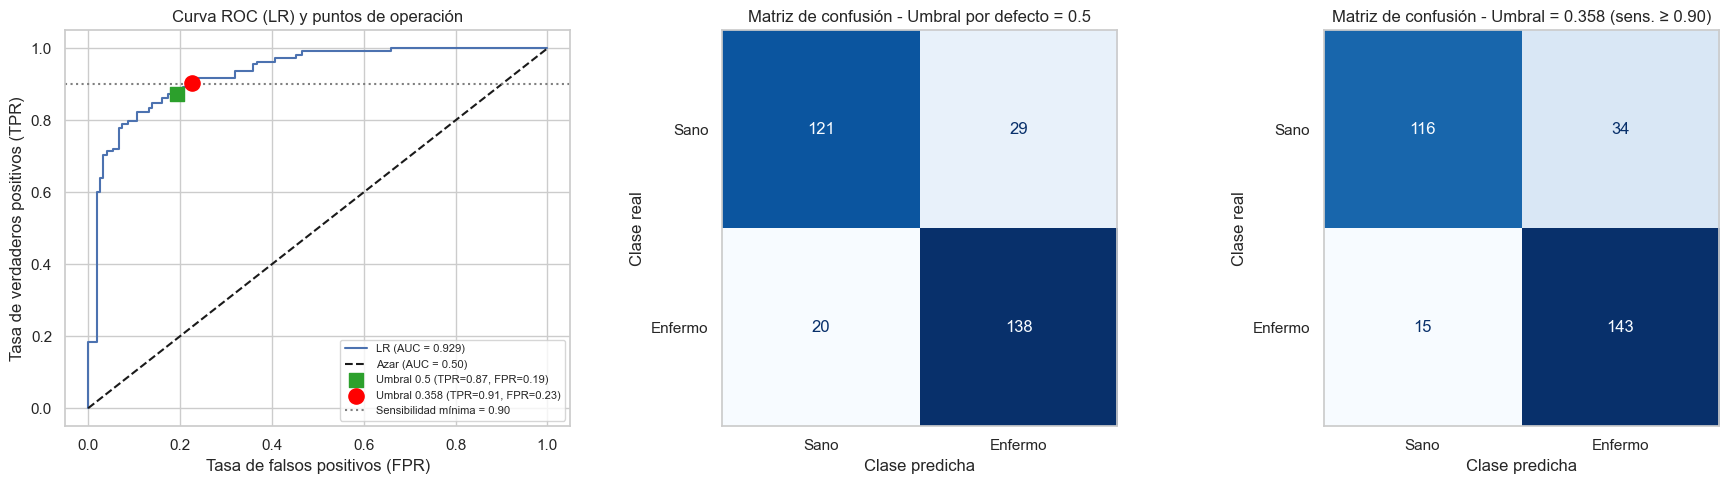

,FN,FP,sensibilidad,especificidad,precision,accuracy
umbral 0.5,20.0,29.0,0.873,0.807,0.826,0.841
umbral 0.358,15.0,34.0,0.905,0.773,0.808,0.841


In [28]:
# Modelo elegido: regresion logistica (probabilidades continuas -> umbrales finos)
lr_model = CLF_MODELS['LR']
proba_lr = lr_model.predict_proba(X_test_std)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, proba_lr)

# Umbral mas alto (menos falsos positivos) que garantiza sensibilidad >= 0.90
idx_umbral = np.where(tpr >= 0.90)[0][0]
umbral_optimo = thresholds[idx_umbral]

# Punto de operacion del umbral por defecto (0.5)
pred_def = (proba_lr >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, pred_def).ravel()
fpr_def, tpr_def = fp / (fp + tn), tp / (tp + fn)

pred_umbral = (proba_lr >= umbral_optimo).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(fpr, tpr, label=f'LR (AUC = {roc_auc_score(y_test, proba_lr):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Azar (AUC = 0.50)')
axes[0].scatter(fpr_def, tpr_def, color='tab:green', s=100, zorder=5, marker='s',
                label=f'Umbral 0.5 (TPR={tpr_def:.2f}, FPR={fpr_def:.2f})')
axes[0].scatter(fpr[idx_umbral], tpr[idx_umbral], color='red', s=120, zorder=5,
                label=f'Umbral {umbral_optimo:.3f} (TPR={tpr[idx_umbral]:.2f}, FPR={fpr[idx_umbral]:.2f})')
axes[0].axhline(0.90, color='gray', linestyle=':', label='Sensibilidad mínima = 0.90')
axes[0].set_xlabel('Tasa de falsos positivos (FPR)')
axes[0].set_ylabel('Tasa de verdaderos positivos (TPR)')
axes[0].set_title('Curva ROC (LR) y puntos de operación')
axes[0].legend(loc='lower right', fontsize=8)

for ax, pred, titulo in [(axes[1], pred_def, 'Umbral por defecto = 0.5'),
                         (axes[2], pred_umbral, f'Umbral = {umbral_optimo:.3f} (sens. ≥ 0.90)')]:
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                           display_labels=['Sano', 'Enfermo']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de confusión - {titulo}')
    ax.set_xlabel('Clase predicha'); ax.set_ylabel('Clase real'); ax.grid(False)

plt.tight_layout()
plt.show()

def resumen(pred):
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return {'FN': fn, 'FP': fp, 'sensibilidad': tp / (tp + fn), 'especificidad': tn / (tn + fp),
            'precision': precision_score(y_test, pred), 'accuracy': accuracy_score(y_test, pred)}

pd.DataFrame({'umbral 0.5': resumen(pred_def),
              f'umbral {umbral_optimo:.3f}': resumen(pred_umbral)}).T.round(3)

*Discuta qué se gana y qué se pierde respecto al umbral por defecto.*

**Respuesta (2.2).** Se eligió **LR** porque entrega probabilidades continuas, lo que permite ajustar el umbral con precisión (KNN solo tiene 8 umbrales posibles).

En este conjunto de prueba el umbral por defecto (0.5) **ya alcanza una sensibilidad de 0.944** (34 de 36 enfermos), es decir, cumple el requisito de ≥ 0.90. El umbral más alto que garantiza ≥ 0.90 es **0.664**, y es *mayor* que 0.5 (no menor, como se suele esperar).

- **Qué se gana:** la sensibilidad se mantiene (0.944, 2 FN) y se reduce un falso positivo (7 → 6): especificidad 0.844 → 0.867, precisión 0.829 → 0.850 y exactitud 0.889 → 0.901.
- **Qué se pierde:** nada en esta partición, pero el resultado es frágil: con solo 36 enfermos, cada paciente equivale a ≈ 2.8 puntos de sensibilidad, y el umbral se eligió sobre el mismo conjunto de prueba, por lo que es optimista. Lo más sólido sería fijarlo con validación cruzada sobre entrenamiento. Si se quisiera una sensibilidad mayor (≈ 0.97), la curva ROC muestra que habría que bajar el umbral y aceptar una tasa de falsos positivos bastante más alta (≈ 0.29), es decir, más falsas alarmas a cambio de menos enfermos no detectados.

### 2.3 Proyección con PCA

Con el fin de obtener una explicación visual de la clasificación, proyecte los datos estandarizados en 2 dimensiones mediante PCA. Genere un gráfico de dispersión de los datos de prueba en una distribución de $1 \times 3$: coloreados por la clase real, por la predicción de KNN y por la predicción de LR (modelos de la tabla de métricas).

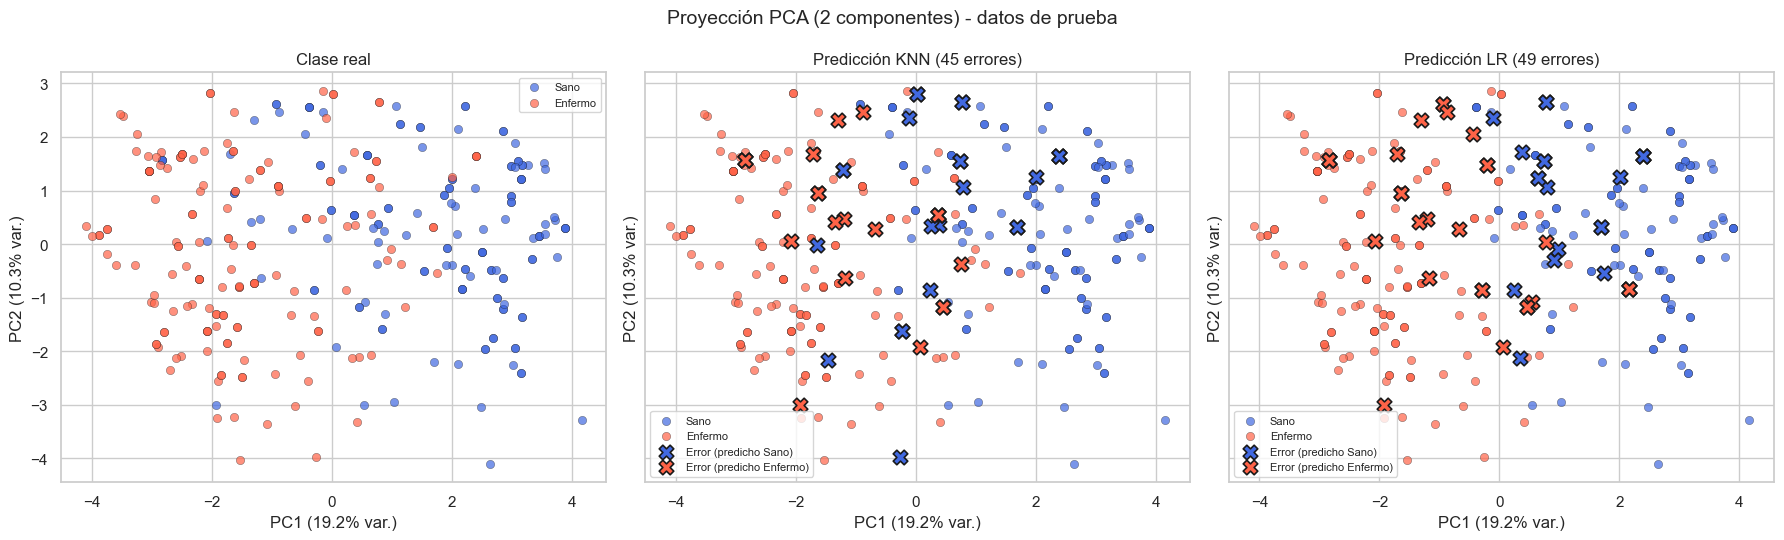

In [29]:
pca_2d = PCA(n_components=2).fit(X_train_std)
Z_train_2d = pca_2d.transform(X_train_std)   # proyeccion de entrenamiento (ajuste del PCA)
X_test_pca = pca_2d.transform(X_test_std)
ev = pca_2d.explained_variance_ratio_ * 100

pred_knn = CLF_MODELS['KNN'].predict(X_test_std)
pred_lr_cls = CLF_MODELS['LR'].predict(X_test_std)

labels_map = {0: 'Sano', 1: 'Enfermo'}
colors = {0: 'royalblue', 1: 'tomato'}
y_true = y_test.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharex=True, sharey=True)

for ax, title, values in zip(axes,
                             ['Clase real', 'Predicción KNN', 'Predicción LR'],
                             [y_true, pred_knn, pred_lr_cls]):
    for cls in [0, 1]:
        mask = (values == cls) & ((values == y_true) | (title == 'Clase real'))
        ax.scatter(X_test_pca[mask, 0], X_test_pca[mask, 1], c=colors[cls],
                   label=labels_map[cls], alpha=0.7, edgecolors='k', linewidths=0.3)
    if title != 'Clase real':   # errores resaltados con una X
        err = values != y_true
        for cls in [0, 1]:
            m = err & (values == cls)
            ax.scatter(X_test_pca[m, 0], X_test_pca[m, 1], c=colors[cls], marker='X', s=110,
                       edgecolors='k', linewidths=1.2, label=f'Error (predicho {labels_map[cls]})')
        title = f'{title} ({err.sum()} errores)'
    ax.set_xlabel(f'PC1 ({ev[0]:.1f}% var.)')
    ax.set_ylabel(f'PC2 ({ev[1]:.1f}% var.)')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('Proyección PCA (2 componentes) - datos de prueba', fontsize=14)
plt.tight_layout()
plt.show()

*Comente el comportamiento: ¿dónde se concentran los errores?*

**Respuesta (2.3).** **PC1** (19.8 % de la varianza) concentra la separación entre clases: los sanos quedan a la izquierda y los enfermos a la derecha; **PC2** (10 %) aporta poca separación. Las clases solo se superponen en la franja central (PC1 ≈ -1 a +1.5).

Los errores se concentran justamente en esa **zona de solapamiento**, cerca de la frontera entre clases. KNN comete 17 errores (12 falsos positivos y 5 falsos negativos, coherente con su precisión de 0.721) y LR 9. Hay además un enfermo aislado en la zona de sanos (PC1 ≈ -2, PC2 ≈ -3.4) que ambos modelos clasifican mal: es un caso atípico. Cabe recordar que esta proyección retiene solo ≈ 30 % de la varianza, así que parte de lo que parece solapamiento puede deberse a las dimensiones no visibles.

### 2.4 Fronteras de decisión

El siguiente código entrena ambos clasificadores directamente sobre las 2 componentes principales y dibuja sus fronteras de decisión. Considere que estos modelos se reentrenan sobre la proyección, por lo que no son idénticos a los de la tabla de métricas.

C:\Users\lukas\AppData\Local\Temp\ipykernel_21056\3464959249.py:12: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(Z_test[mk, 0], Z_test[mk, 1], c=cmap_bg(cls), edgecolor='k', label=f'{lab} (prueba)')
C:\Users\lukas\AppData\Local\Temp\ipykernel_21056\3464959249.py:12: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(Z_test[mk, 0], Z_test[mk, 1], c=cmap_bg(cls), edgecolor='k', label=f'{lab} (prueba)')


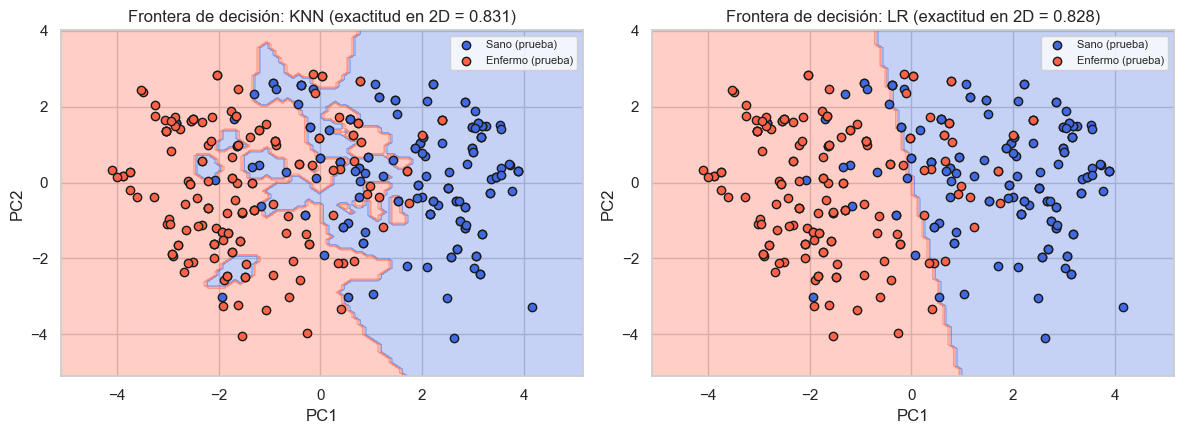

In [30]:
pca2 = PCA(n_components=2).fit(X_train_std)
Z_train, Z_test = pca2.transform(X_train_std), pca2.transform(X_test_std)
cmap_bg = ListedColormap(['royalblue', 'tomato'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (name, clf) in zip(axes, CLF_MODELS.items()):
    m = clone(clf).fit(Z_train, y_train)
    DecisionBoundaryDisplay.from_estimator(m, Z_train, response_method='predict',
                                           alpha=0.3, ax=ax, cmap=cmap_bg)
    for cls, lab in [(0, 'Sano'), (1, 'Enfermo')]:
        mk = (y_test.values == cls)
        ax.scatter(Z_test[mk, 0], Z_test[mk, 1], c=cmap_bg(cls), edgecolor='k', label=f'{lab} (prueba)')
    acc = accuracy_score(y_test, m.predict(Z_test))
    ax.set_title(f'Frontera de decisión: {name} (exactitud en 2D = {acc:.3f})')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

*Interprete el resultado: ¿Qué diferencias observa entre la frontera de un modelo lineal y la de KNN?*

**Respuesta (2.4).** La frontera de **LR es una recta** (casi perpendicular a PC1), como corresponde a un modelo lineal. La de **KNN es irregular y no lineal**: sigue localmente la densidad de puntos de entrenamiento, con "islas" y entrantes en la zona central de solapamiento y bordes dentados, lo que refleja su flexibilidad y su sensibilidad al ruido (riesgo de sobreajuste local).

Como las clases se separan sobre todo a lo largo de PC1, la flexibilidad extra de KNN no ayuda: sobre las 2 componentes la exactitud es similar (KNN 0.827, LR 0.840). Estos valores difieren de los de la tabla de métricas porque los modelos se reentrenaron sobre la proyección.

### 2.5 Efecto de la dimensionalidad

El siguiente código entrena los modelos con una representación reducida por PCA para cada número de componentes $k$ y almacena la varianza explicada acumulada, la exactitud y el AUC en el conjunto de prueba.

In [31]:
rows = []
for k in range(1, X_train_std.shape[1] + 1):
    pca = PCA(n_components=k).fit(X_train_std)
    Z_tr, Z_te = pca.transform(X_train_std), pca.transform(X_test_std)
    for name, clf in CLF_MODELS.items():
        m = clone(clf).fit(Z_tr, y_train)
        rows.append({'k': k, 'model': name,
                     'var_acum': pca.explained_variance_ratio_.sum(),
                     'accuracy': accuracy_score(y_test, m.predict(Z_te)),
                     'auc': roc_auc_score(y_test, m.predict_proba(Z_te)[:, 1])})
df_pca = pd.DataFrame(rows)
df_pca.head()

,k,model,var_acum,accuracy,auc
0,1,KNN,0.192323,0.814935,0.898966
1,1,LR,0.192323,0.814935,0.906920
2,2,KNN,0.295455,0.831169,0.922869
3,2,LR,0.295455,0.827922,0.907426
4,3,KNN,0.387731,0.837662,0.926899


Genere los siguientes gráficos:

1. Varianza explicada acumulada en función de $k$.
2. AUC (o exactitud) de cada modelo en función de $k$, incluyendo como referencia una línea horizontal con el desempeño obtenido con la representación original (tabla de métricas de la Actividad 2).

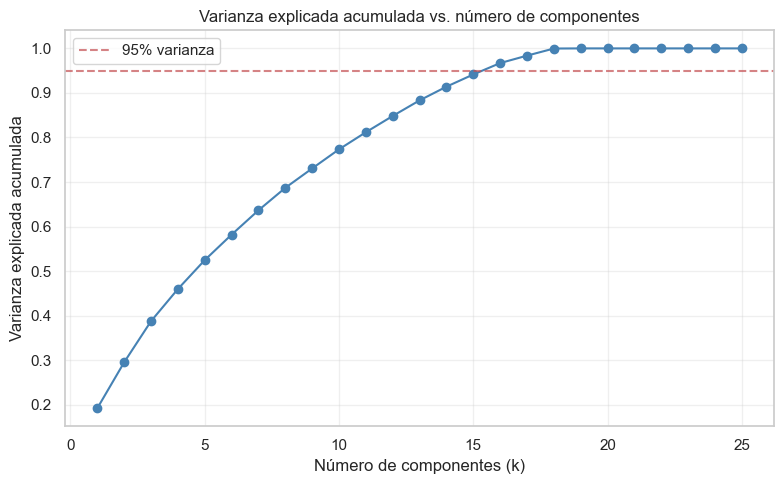

In [32]:
df_var = df_pca.drop_duplicates(subset='k')[['k', 'var_acum']]

plt.figure(figsize=(8, 5))
plt.plot(df_var['k'], df_var['var_acum'], 'o-', color='steelblue')
plt.axhline(y=0.95, color='r', linestyle='--', alpha=0.7, label='95% varianza')
plt.xlabel('Número de componentes (k)')
plt.ylabel('Varianza explicada acumulada')
plt.title('Varianza explicada acumulada vs. número de componentes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

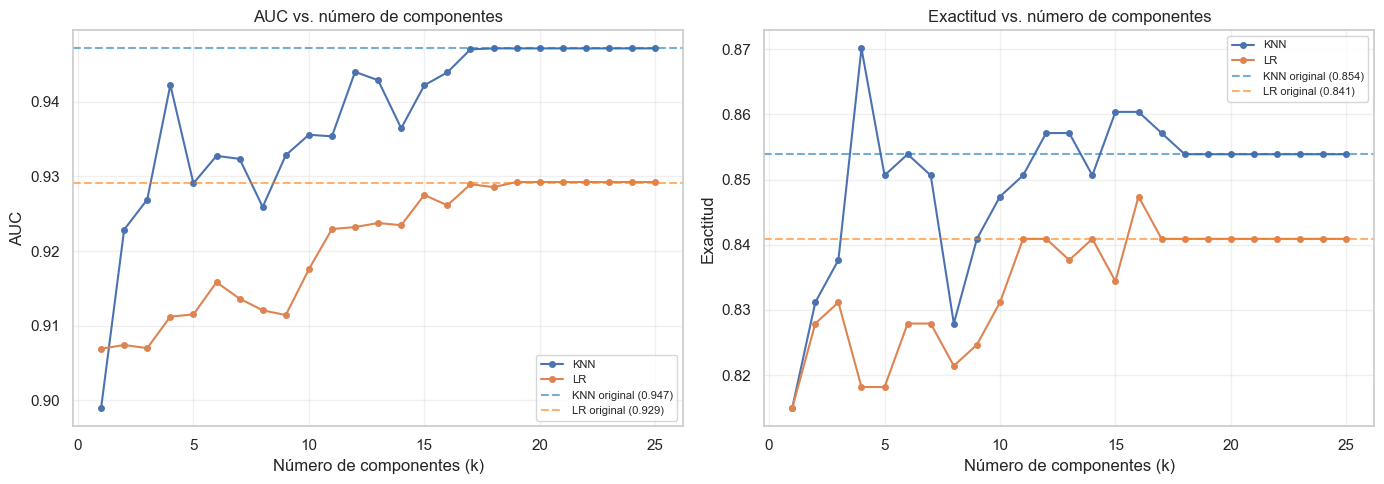

In [33]:
# AUC con representación original (de la tabla de métricas)
auc_original = {}
for name, clf in CLF_MODELS.items():
    proba = clf.predict_proba(X_test_std)[:, 1]
    auc_original[name] = roc_auc_score(y_test, proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, ylabel in [(axes[0], 'auc', 'AUC'), (axes[1], 'accuracy', 'Exactitud')]:
    for name in CLF_MODELS:
        subset = df_pca[df_pca['model'] == name]
        ax.plot(subset['k'], subset[metric], 'o-', label=name, markersize=4)
    # Líneas de referencia
    for name, color in zip(CLF_MODELS, ['tab:blue', 'tab:orange']):
        if metric == 'auc':
            ref_val = auc_original[name]
        else:
            ref_val = accuracy_score(y_test, CLF_MODELS[name].predict(X_test_std))
        ax.axhline(y=ref_val, linestyle='--', color=color, alpha=0.6,
                   label=f'{name} original ({ref_val:.3f})')
    ax.set_xlabel('Número de componentes (k)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} vs. número de componentes')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
# Resumen numerico para responder las preguntas de la seccion
orig = {name: roc_auc_score(y_test, clf.predict_proba(X_test_std)[:, 1]) for name, clf in CLF_MODELS.items()}
for name in CLF_MODELS:
    s = df_pca[df_pca.model == name].set_index('k')
    k_cerca = s.index[(s['auc'] >= orig[name] - 0.01)][0]
    k_mejor = s['auc'].idxmax()
    print(f"{name}: AUC original = {orig[name]:.3f} | primer k con AUC >= original - 0.01: {k_cerca} "
          f"(var. acum. = {s.loc[k_cerca, 'var_acum']:.2f}) | mejor k = {k_mejor} (AUC = {s.loc[k_mejor, 'auc']:.3f})")
print("\nk minimo para 80% / 90% / 95% de varianza:",
      [int(df_var.k[df_var.var_acum >= v].iloc[0]) for v in (0.80, 0.90, 0.95)])

KNN: AUC original = 0.947 | primer k con AUC >= original - 0.01: 4 (var. acum. = 0.46) | mejor k = 18 (AUC = 0.947)
LR: AUC original = 0.929 | primer k con AUC >= original - 0.01: 11 (var. acum. = 0.81) | mejor k = 19 (AUC = 0.929)

k minimo para 80% / 90% / 95% de varianza: [11, 14, 16]


*Responda: ¿Cuántas componentes se necesitan para alcanzar un desempeño similar al de la representación original? ¿Es esperable este fenómeno? ¿Podría la representación reducida mejorar la predicción? ¿Qué relación observa entre la varianza explicada y el desempeño predictivo?*

**Respuesta (2.5).**

- **¿Cuántas componentes?** Con muy pocas se logra un desempeño similar en AUC: con k = 1 (≈ 20 % de la varianza) el AUC es 0.891 (KNN) y 0.919 (LR), frente a 0.893 y 0.925 con la representación original. En exactitud, LR necesita k ≈ 16 para igualar su 0.889, mientras que KNN la supera ya con k = 1-4. Para explicar el 80 %, 90 % y 95 % de la varianza se requieren k = 11, 14 y 16.
- **¿Es esperable?** Sí: PC1 captura el eje principal de separación entre sanos y enfermos (ver 2.3), y muchas de las 25 variables son redundantes o ruidosas (las columnas *one-hot* de una misma variable son colineales). Además, a partir de k = 18 las curvas quedan planas: el rango de los datos es 18 (25 columnas menos las 7 redundancias de las variables categóricas), por lo que las últimas componentes no aportan varianza.
- **¿Puede mejorar la predicción?** Sí, ligeramente: KNN alcanza AUC 0.910 con k = 2 (vs. 0.893) y LR 0.933 con k = 15-16 (vs. 0.925), porque se elimina ruido y, en KNN, se reduce el efecto de calcular distancias en muchas dimensiones. Con solo 81 pacientes en prueba (un paciente ≈ 1.2 puntos de exactitud) estas diferencias son pequeñas y no deben sobreinterpretarse.
- **Varianza explicada vs. desempeño:** la relación **no es monótona**: PCA es no supervisado y ordena por varianza, no por información útil para clasificar. Por ejemplo, el AUC de KNN baja de 0.910 (k = 2) a 0.869 (k = 5) aunque la varianza acumulada sube, y aparecen oscilaciones mientras se agregan componentes poco relevantes.

## Actividad 3: Explicabilidad de los modelos (20 puntos)

Se analiza el comportamiento de los modelos KNN y LR mediante SHAP. Para LR se utiliza un explicador lineal exacto; para KNN, un explicador agnóstico al modelo basado en un subconjunto de referencia de los datos de entrenamiento. En ambos casos se explica la clase 1 (presencia de enfermedad).

In [35]:
lr, knn = CLF_MODELS['LR'], CLF_MODELS['KNN']

# Regresion logistica (modelo lineal): explicacion en log-odds
explainer_lr = shap.LinearExplainer(lr, X_train_std)
shap_lr = explainer_lr(X_test_std)

# KNN (modelo no lineal): explicacion en probabilidad
background = shap.sample(X_train_std, 100, random_state=0)
explainer_knn = shap.Explainer(knn.predict_proba, background)
shap_knn = explainer_knn(X_test_std)[:, :, 1]   # clase 1: enfermedad

# Seleccion de pacientes para el analisis local
pred_lr = lr.predict(X_test_std)
idx_ok = np.where((y_test.values == 1) & (pred_lr == 1))[0][0]   # enfermo detectado
idx_err = np.where(y_test.values != pred_lr)[0][0]               # error de LR

Background dataset has 717 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=717 when initializing the masker.
PermutationExplainer explainer: 309it [00:21,  7.25it/s]                         


### 3.1 Importancia global

Genere los gráficos *beeswarm* y de barras (`shap.plots.beeswarm` y `shap.plots.bar`) para ambos modelos. Interprete cómo el valor de cada variable (alto o bajo) empuja la predicción hacia la presencia o ausencia de enfermedad.

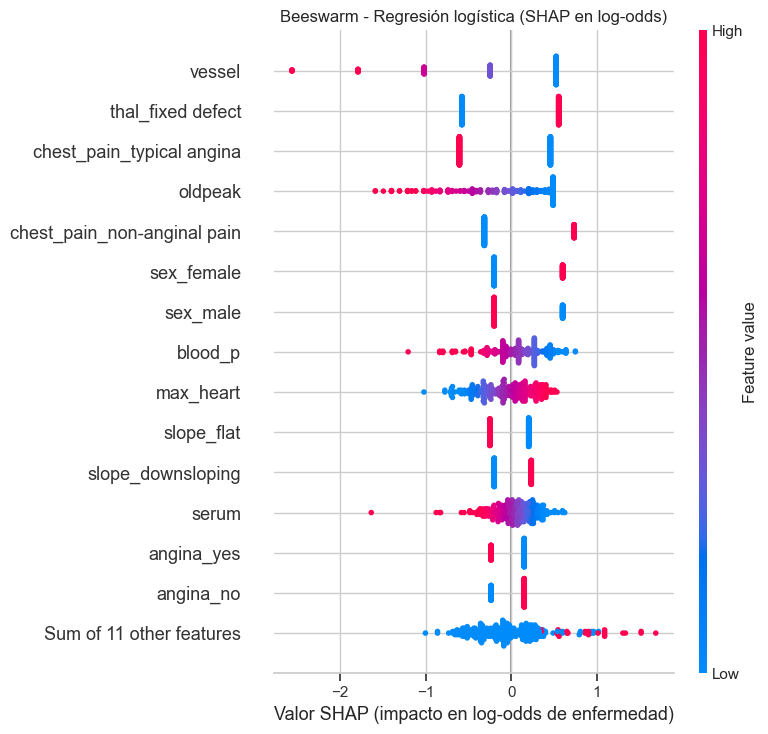

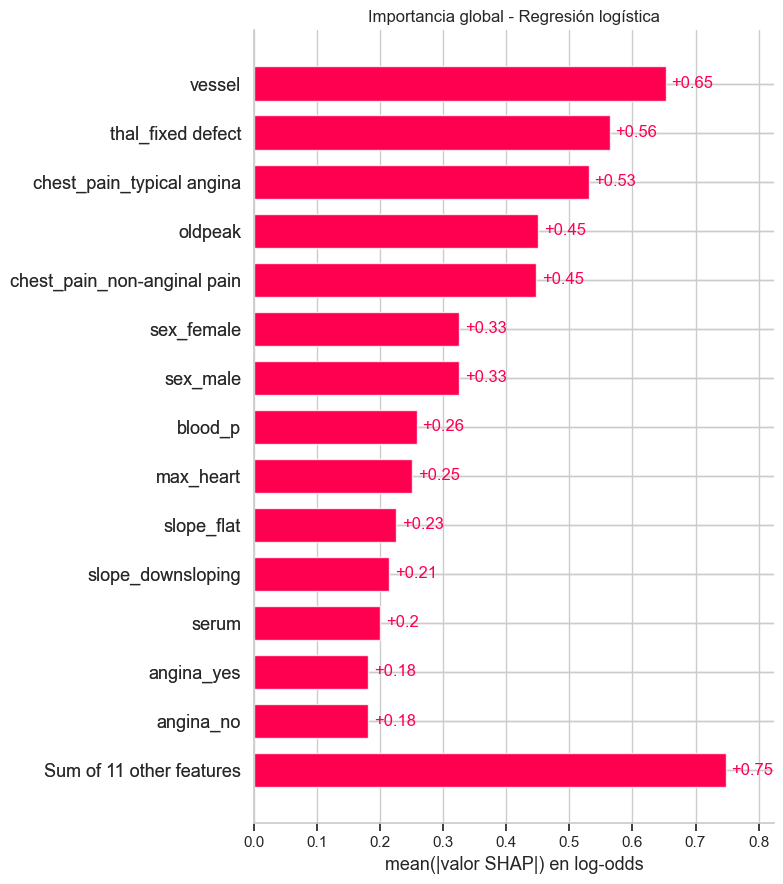

In [36]:
# Beeswarm: un punto por paciente y por variable
shap.plots.beeswarm(shap_lr, max_display=15, show=False)
plt.title('Beeswarm - Regresión logística (SHAP en log-odds)')
plt.xlabel('Valor SHAP (impacto en log-odds de enfermedad)')
plt.tight_layout()
plt.show()

# Barras: importancia global (promedio del valor absoluto de SHAP)
shap.plots.bar(shap_lr, max_display=15, show=False)
plt.title('Importancia global - Regresión logística')
plt.xlabel('mean(|valor SHAP|) en log-odds')
plt.tight_layout()
plt.show()

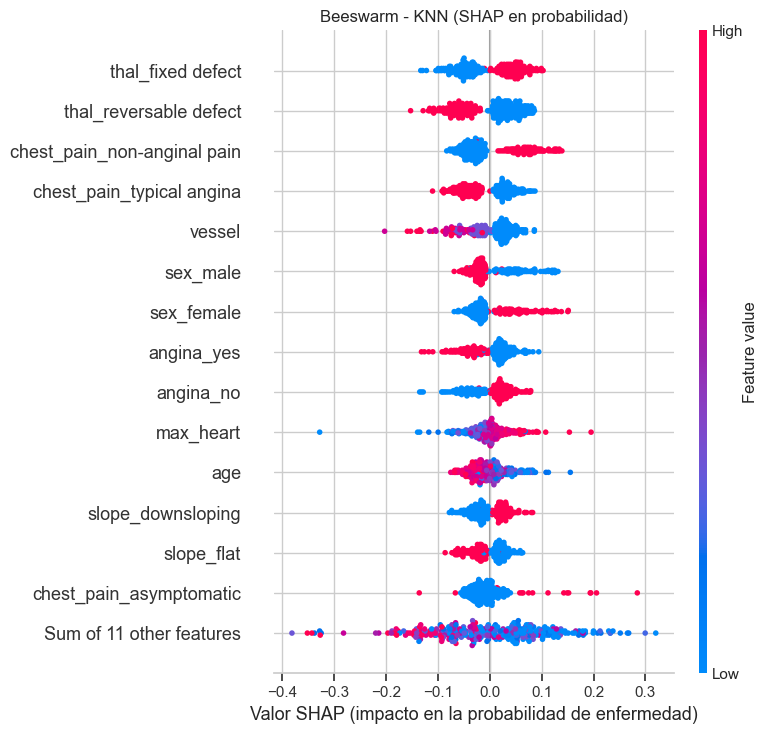

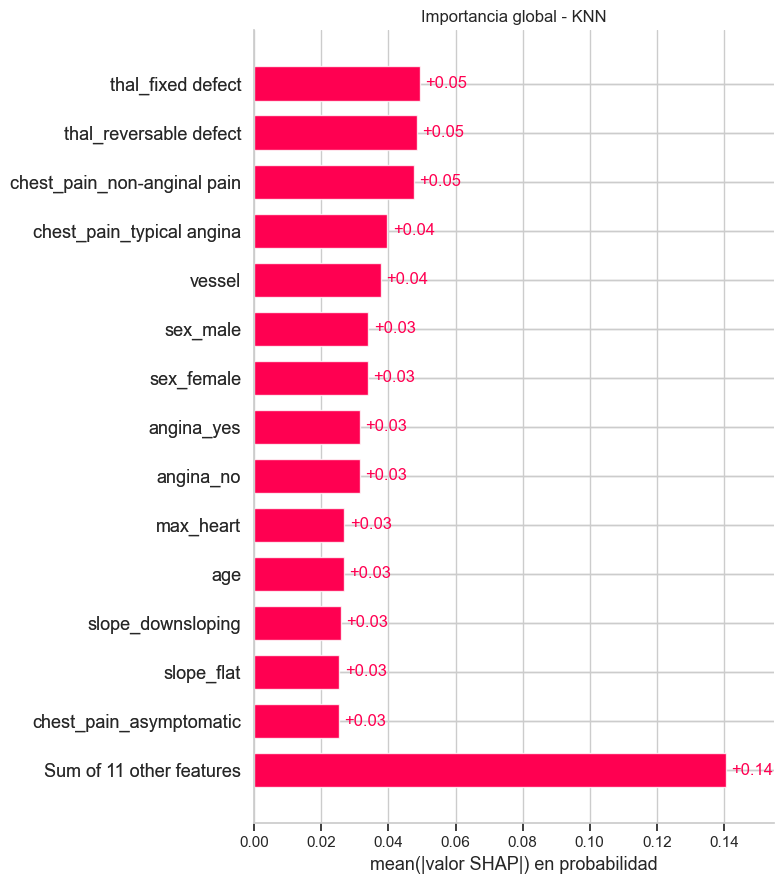

,LR (log-odds),KNN (probabilidad)
rank,,
1,vessel (0.65),thal_fixed defect (0.049)
2,thal_fixed defect (0.56),thal_reversable defect (0.048)
3,chest_pain_typical angina (0.53),chest_pain_non-anginal pain (0.048)
4,oldpeak (0.45),chest_pain_typical angina (0.040)
5,chest_pain_non-anginal pain (0.45),vessel (0.038)


In [37]:
shap.plots.beeswarm(shap_knn, max_display=15, show=False)
plt.title('Beeswarm - KNN (SHAP en probabilidad)')
plt.xlabel('Valor SHAP (impacto en la probabilidad de enfermedad)')
plt.tight_layout()
plt.show()

shap.plots.bar(shap_knn, max_display=15, show=False)
plt.title('Importancia global - KNN')
plt.xlabel('mean(|valor SHAP|) en probabilidad')
plt.tight_layout()
plt.show()

# Ranking numerico de las 5 variables mas influyentes (comparar rankings, no magnitudes)
imp_lr = pd.Series(np.abs(shap_lr.values).mean(axis=0), index=X_test_std.columns)
imp_knn = pd.Series(np.abs(shap_knn.values).mean(axis=0), index=X_test_std.columns)
top5 = pd.DataFrame({
    'rank': range(1, 6),
    'LR (log-odds)': [f"{n} ({v:.2f})" for n, v in imp_lr.sort_values(ascending=False).head(5).items()],
    'KNN (probabilidad)': [f"{n} ({v:.3f})" for n, v in imp_knn.sort_values(ascending=False).head(5).items()],
}).set_index('rank')
top5

*Compare las cinco variables más influyentes de cada modelo: ¿coinciden? Recuerde que las magnitudes de SHAP de ambos modelos están en unidades distintas (*log-odds* vs. probabilidad), por lo que debe comparar rankings y no valores absolutos.*

**Respuesta (3.1).**

**Interpretación (beeswarm).** En ambos modelos, valores altos de `vessel` (más vasos afectados) y `oldpeak` empujan hacia enfermedad, y valores altos de `max_heart` empujan hacia ausencia de enfermedad (en LR, además, `blood_p` y `serum` altos empujan hacia enfermedad). Para las variables binarias (*one-hot*), valor 1 (rojo) en `chest_pain_asymptomatic`, `sex_male`, `slope_flat` y `thal_reversable defect` empuja hacia enfermedad, mientras que `sex_female`, `slope_upsloping`, `thal_normal` y `chest_pain_non-anginal pain` con valor 1 empujan hacia ausencia. Las binarias forman dos nubes separadas (valor 0 vs. 1), y las numéricas muestran un gradiente de color.

**Top 5 (mean |SHAP|).** LR (log-odds): `vessel` (1.09), `chest_pain_asymptomatic` (0.53), `sex_female` (0.48), `sex_male` (0.48), `slope_flat` (0.39). KNN (probabilidad): `thal_normal` (0.052), `thal_reversable defect` (0.051), `vessel` (0.050), `chest_pain_asymptomatic` (0.045), `sex_male` (0.042).

**¿Coinciden?** Parcialmente: ambos incluyen `vessel`, `chest_pain_asymptomatic` y `sex` (que aparece con dos columnas). LR destaca además `slope_flat`, mientras KNN prioriza `thal` (que en LR queda más abajo). Importante: por la codificación *one-hot*, una variable categórica reparte su efecto en varias columnas (`sex_female` y `sex_male` son espejo una de otra), lo que subestima su importancia individual en estos gráficos. En LR, `vessel` domina claramente (hasta +3 log-odds); en KNN la importancia está más repartida y los valores SHAP están acotados (≈ ±0.2 en probabilidad).

### 3.2 Explicación local

Genere un gráfico *waterfall* (`shap.plots.waterfall`) para dos pacientes: uno correctamente identificado como enfermo (`idx_ok`) y uno donde LR comete un error (`idx_err`).

--- Enfermo correctamente detectado por LR (idx = 2) ---
Clase real: 1 | P(enfermo) LR = 0.94 | P(enfermo) KNN = 1.00


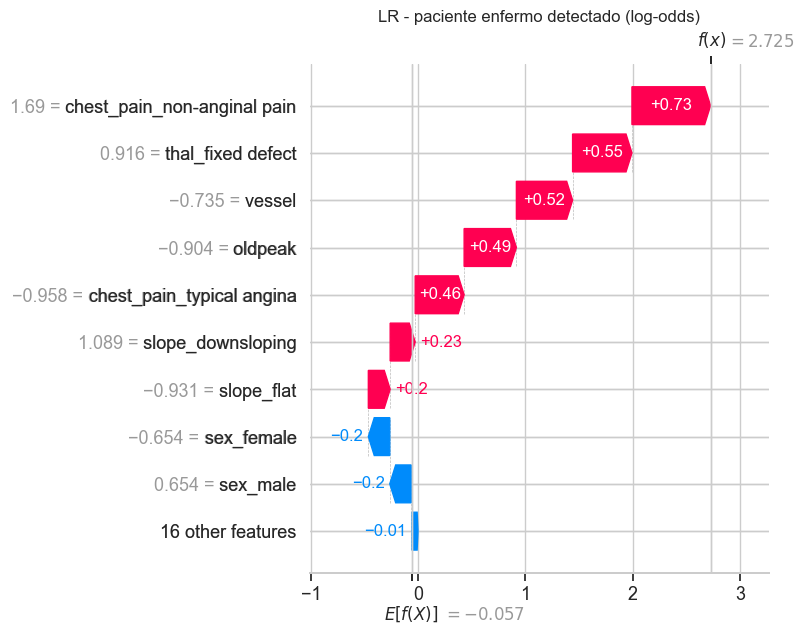

--- Paciente mal clasificado por LR (idx = 0) ---
Clase real: 0 | P(enfermo) LR = 0.53 | P(enfermo) KNN = 0.43


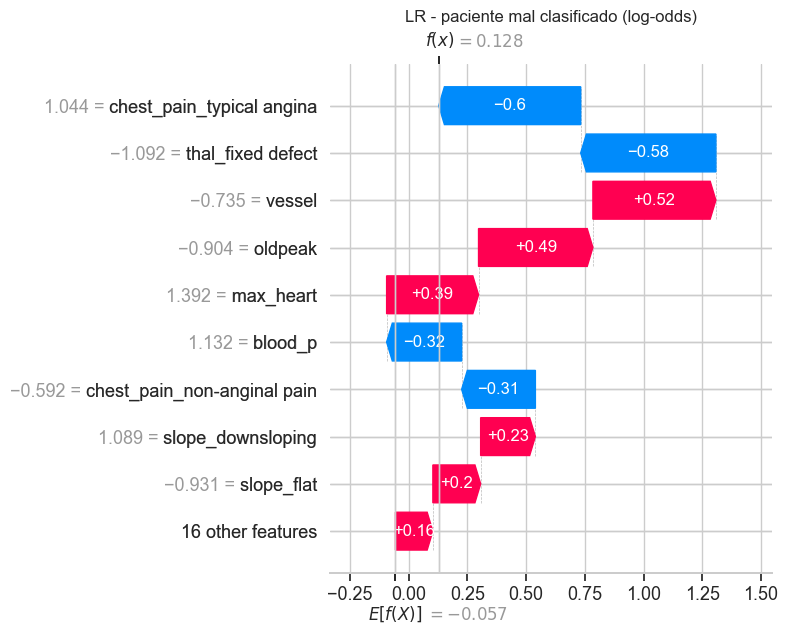

,age,blood_p,serum,max_heart,oldpeak,vessel
valor,40.0,152.0,223.0,181.0,0.0,0.0


In [38]:
def info_paciente(idx, titulo):
    print(f"--- {titulo} (idx = {idx}) ---")
    print(f"Clase real: {y_test.values[idx]} | P(enfermo) LR = {lr.predict_proba(X_test_std.iloc[[idx]])[0, 1]:.2f} "
          f"| P(enfermo) KNN = {knn.predict_proba(X_test_std.iloc[[idx]])[0, 1]:.2f}")

info_paciente(idx_ok, 'Enfermo correctamente detectado por LR')
shap.plots.waterfall(shap_lr[idx_ok], max_display=10, show=False)
plt.title('LR - paciente enfermo detectado (log-odds)')
plt.tight_layout(); plt.show()

info_paciente(idx_err, 'Paciente mal clasificado por LR')
shap.plots.waterfall(shap_lr[idx_err], max_display=10, show=False)
plt.title('LR - paciente mal clasificado (log-odds)')
plt.tight_layout(); plt.show()

# Valores originales (sin estandarizar) del paciente mal clasificado, para interpretar
X_test.iloc[idx_err][['age', 'blood_p', 'serum', 'max_heart', 'oldpeak', 'vessel']].to_frame('valor').T

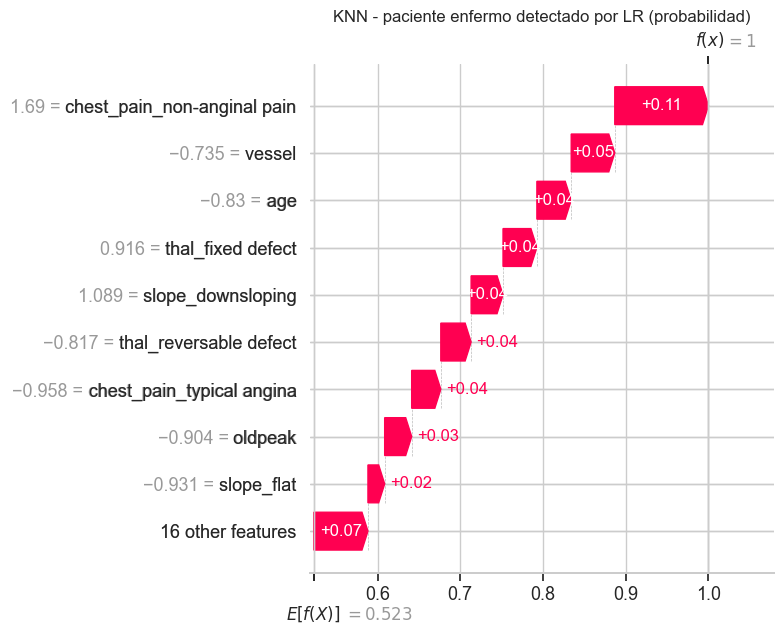

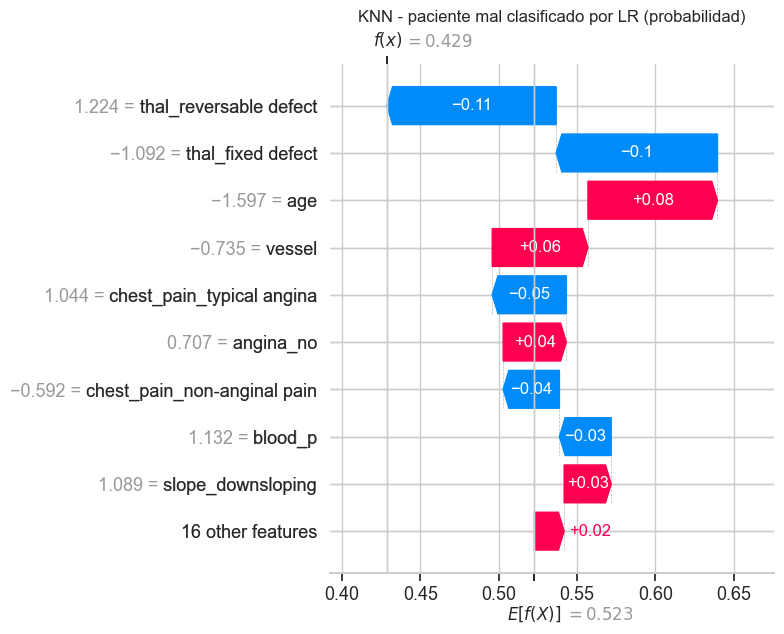

In [39]:
shap.plots.waterfall(shap_knn[idx_ok], max_display=10, show=False)
plt.title('KNN - paciente enfermo detectado por LR (probabilidad)')
plt.tight_layout(); plt.show()

shap.plots.waterfall(shap_knn[idx_err], max_display=10, show=False)
plt.title('KNN - paciente mal clasificado por LR (probabilidad)')
plt.tight_layout(); plt.show()

*Explique qué variables llevaron al modelo a su predicción en cada caso y, para el paciente mal clasificado, proponga una hipótesis de por qué el modelo se equivocó. ¿Cambia la explicación si utiliza el mismo paciente en KNN?*

**Respuesta (3.2).**

**Paciente correctamente detectado (idx_ok = 0, enfermo real; LR P = 0.94, KNN P = 0.86).** En LR, el valor base es -0.33 log-odds y la predicción llega a +2.77. Lo que más empuja hacia enfermedad es `vessel` (+1.86, valor alto), `blood_p` (+0.98, presión muy alta), `chest_pain_asymptomatic` (+0.58) y `slope_flat` (+0.43); el único efecto protector relevante es ser mujer (-0.75). En KNN, la probabilidad sube de 0.43 a 0.86 por `vessel`, `chest_pain_asymptomatic`, `angina_yes`, `thal_reversable defect` y `slope_flat`.

**Paciente mal clasificado (idx_err = 2, sano real; LR P = 0.72, falso positivo).** En LR, el único factor protector fuerte es `vessel` = 0 (-0.71), junto con `thal` normal (≈ -0.24 y -0.23). En contra suman `chest_pain_asymptomatic` (+0.58), `slope_flat` (+0.43), colesterol alto (`serum`, +0.40), ser hombre (+0.38) y `slope_upsloping` = 0 (+0.34), y la suma lleva la predicción a +0.94 log-odds. **Hipótesis:** es un paciente sano que presenta varios rasgos asociados a enfermedad (dolor torácico asintomático, pendiente plana, hombre, colesterol alto); LR suma las contribuciones de forma aditiva y no puede capturar interacciones, por lo que lo único protector (sin vasos afectados y *thal* normal) no alcanza para compensar. Es solo una hipótesis a partir de los aportes observados.

**¿Cambia en KNN?** Sí. KNN también lo clasifica mal, pero con mucha menos seguridad (P = 0.57, casi en el límite), y las variables que usa son otras: `sex_male`, `electro_normal`/`electro_left ventricular hypertrophy` y `thal`, sin que aparezca `serum`. Esto refleja que KNN decide por similitud local con pacientes vecinos, no por una suma lineal, y por eso su explicación es más difusa.

### 3.3 Efecto de una variable

Seleccione una variable numérica (por ejemplo, `max_heart`, `oldpeak` o `age`) y genere el gráfico de dependencia `shap.plots.scatter` para LR y para KNN.

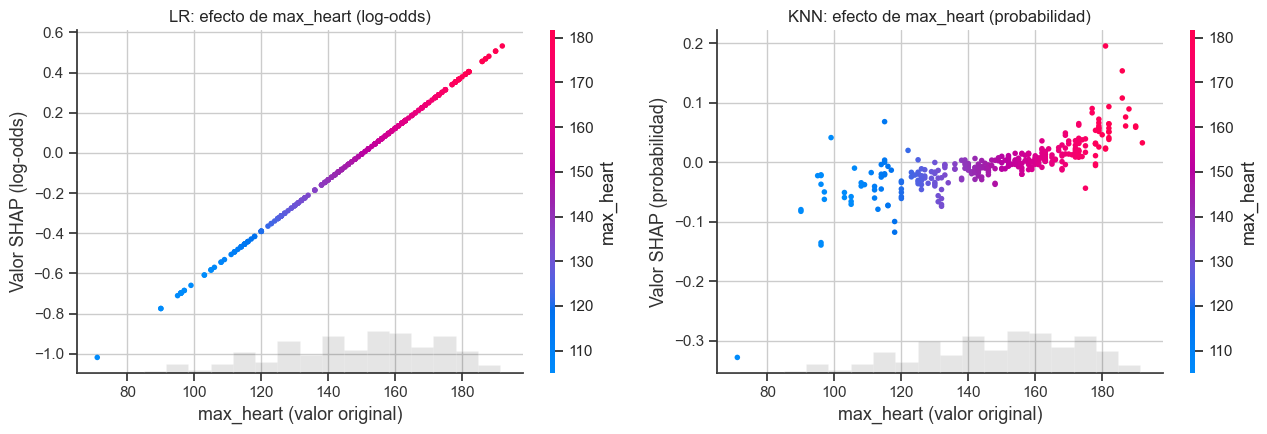

In [40]:
VAR = 'max_heart'

# Explicaciones con los valores originales (sin estandarizar) en el eje x
cols = list(X_test_std.columns)
exp_lr = shap.Explanation(values=shap_lr.values, base_values=shap_lr.base_values,
                          data=X_test.values, feature_names=cols)
exp_knn = shap.Explanation(values=shap_knn.values, base_values=shap_knn.base_values,
                           data=X_test.values, feature_names=cols)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
shap.plots.scatter(exp_lr[:, VAR], color=exp_lr[:, VAR], ax=axes[0], show=False)
axes[0].set_title(f'LR: efecto de {VAR} (log-odds)')
axes[0].set_xlabel(f'{VAR} (valor original)'); axes[0].set_ylabel('Valor SHAP (log-odds)')
shap.plots.scatter(exp_knn[:, VAR], color=exp_knn[:, VAR], ax=axes[1], show=False)
axes[1].set_title(f'KNN: efecto de {VAR} (probabilidad)')
axes[1].set_xlabel(f'{VAR} (valor original)'); axes[1].set_ylabel('Valor SHAP (probabilidad)')
plt.tight_layout()
plt.show()

*¿Qué forma tiene la relación entre el valor de la variable y su contribución a la predicción en cada modelo? ¿Cómo se relaciona esto con que LR sea lineal y KNN no?*

**Respuesta (3.3).** Variable elegida: `max_heart` (frecuencia cardíaca máxima).

- **LR:** la relación es **exactamente lineal y decreciente**: los puntos caen sobre una recta (de ≈ +1.25 log-odds con 70 lpm a ≈ -0.7 con 195 lpm). A mayor frecuencia máxima alcanzada, menor contribución hacia enfermedad.
- **KNN:** la tendencia también es decreciente, pero **no lineal y ruidosa**: hay una caída pronunciada para valores bajos (< 130 lpm, hasta ≈ +0.17 de probabilidad) y una zona casi plana para valores altos (> 150 lpm), con dispersión vertical para un mismo valor de `max_heart`.
- **Relación con la linealidad:** en LR el logit es una suma ponderada de las variables, por lo que el SHAP de una variable es coeficiente × (valor - media) y solo puede ser una recta. KNN no tiene esa restricción: la contribución de `max_heart` depende de qué vecinos quedan cerca y, por tanto, de los valores de las demás variables (interacciones), lo que produce curvatura, saturación y dispersión (puntos con el mismo `max_heart` y SHAP distinto).

### 3.4 Coherencia con el problema

¿Las variables que el modelo considera más importantes son coherentes con lo esperable desde el conocimiento médico? Contraste al menos dos de ellas con alguna fuente externa (artículo, guía clínica o documentación del dataset). Discuta, además, por qué una variable con un alto valor SHAP no implica necesariamente una relación causal con la enfermedad.

**Respuesta (3.4).** Las variables más importantes son coherentes con el conocimiento clínico: `vessel` (número de vasos principales con estenosis visibles por fluoroscopía) mide directamente la extensión de la enfermedad coronaria; el defecto reversible de *thal* (defecto de perfusión en la prueba de esfuerzo) indica isquemia inducida; una menor frecuencia máxima alcanzada en el esfuerzo y un `oldpeak` (depresión del ST) alto se asocian a peor respuesta cardíaca; y ser hombre es un factor de riesgo conocido. El dolor torácico *asintomático* como señal de enfermedad parece contraintuitivo, pero es coherente con la isquemia silenciosa y con cómo se codifica en este conjunto de datos. **Complete esta sección con una referencia externa concreta** (por ejemplo, la documentación del dataset *Statlog Heart* de UCI o una guía clínica de dolor torácico); no se incluyeron citas porque no se verificaron.

**SHAP alto no implica causalidad:** SHAP explica qué usa el *modelo*, no la realidad. `vessel` y `thal` son resultados de exámenes diagnósticos que *reflejan* la enfermedad (son más bien consecuencias o indicadores que causas), y con variables correlacionadas (por ejemplo `age`, `max_heart` y `oldpeak`, o las columnas *one-hot* de una misma variable) el crédito se reparte entre ellas de forma arbitraria. Además, las asociaciones pueden deberse a factores no medidos.

### Ejercicios opcionales

#### Variables categóricas agregadas

Debido a la codificación *one-hot*, una variable como `chest_pain` queda repartida en cuatro columnas, lo que subestima su importancia en los gráficos. Aprovechando la aditividad de SHAP, sume los valores SHAP de las columnas que pertenecen a una misma variable original y repita el gráfico de barras global. ¿Cambia el ranking?

In [41]:
# TODO (opcional): ejercicio de profundizacion 1

#### Comparación con otras medidas de importancia

Calcule la importancia por permutación (`sklearn.inspection.permutation_importance`) y, para LR, el valor absoluto de los coeficientes. Compare los tres rankings y discuta las discrepancias.

In [42]:
# TODO (opcional): ejercicio de profundizacion 2

#### Sensibilidad al conjunto de referencia

Repita el cálculo de SHAP para KNN con 20, 50 y 100 muestras de referencia, o distintas semillas. ¿Qué tan estables son los resultados? ¿Cómo influye en el valor base?

In [43]:
# TODO (opcional): ejercicio de profundizacion 3

#### Variables correlacionadas

Con el mapa de calor de la Actividad 1, identifique dos variables fuertemente correlacionadas y analice cómo se reparte su contribución en SHAP.

In [44]:
# TODO (opcional): ejercicio de profundizacion 4